# Question 10 
### Is there a correlation between a player's height and their ranking?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

IN_DIR = "cleaned_data"
home = pd.read_parquet(f"{IN_DIR}/home_team.parquet")
away = pd.read_parquet(f"{IN_DIR}/away_team.parquet")
players_unique = pd.concat([home, away], ignore_index=True).drop_duplicates(subset="player_id")

In [2]:
sub = players_unique[["height", "current_rank"]].dropna()
print(f"Players with both height and current_rank available: {len(sub)} "
      f"(out of {len(players_unique)} unique players)")

corr = sub["height"].corr(sub["current_rank"])
print(f"\nAnswer to Question 10:")
print(f"Pearson correlation between height and current_rank: {corr:.3f}")

Players with both height and current_rank available: 1307 (out of 2644 unique players)

Answer to Question 10:
Pearson correlation between height and current_rank: 0.106


#### =======================================================================
#### Chart -- scatter plot of height vs. rank
#### Goal: a single correlation number can hide the actual shape of the relationship (e.g. driven by a few outliers). The scatter plot lets you see the real pattern behind the number.
#### =======================================================================

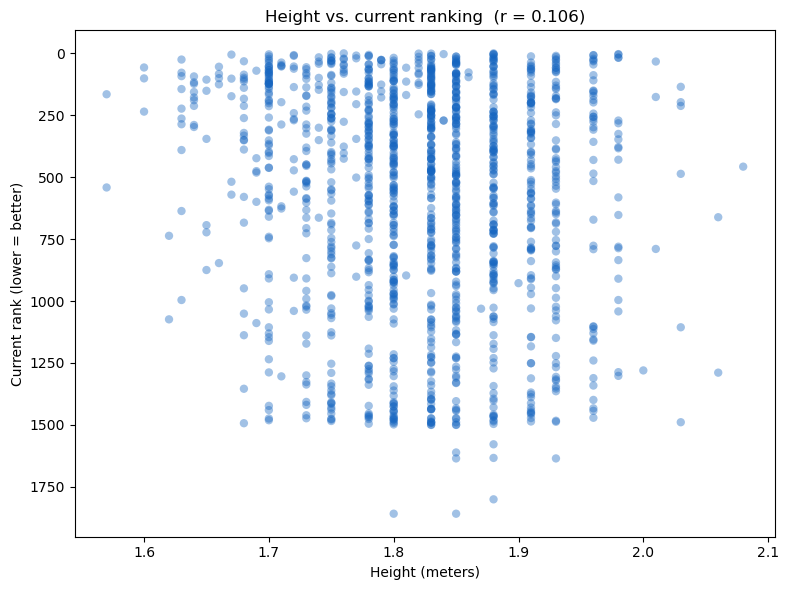

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(sub["height"], sub["current_rank"], alpha=0.4, color="#1565c0", edgecolor="none")
plt.title(f"Height vs. current ranking  (r = {corr:.3f})")
plt.xlabel("Height (meters)")
plt.ylabel("Current rank (lower = better)")
plt.gca().invert_yaxis()  # rank 1 is the best, so flip the axis for intuition
plt.tight_layout()
plt.savefig('charts/q10_Height vs. current ranking.png', dpi=200)
plt.show()

### =======================================================================
## FINDINGS SUMMARY -- Question 10
### =======================================================================

### Question 10: Is there a correlation between a player's height and their ranking?

## Answer:
Pearson r = 0.106, based on 1,307 players (49.4% of the 2,644
unique players -- the rest are missing either height or current_rank).

Interpretation:
The correlation is positive but very weak (|r| < 0.2 is generally
considered negligible). This means there is NO meaningful linear
relationship between a player's height and their current ranking in
this dataset. The scatter plot confirms this visually: at every height
value, players are spread across the full range of rankings (from top
to bottom), rather than clustering toward better rankings for taller
players.

The slightly positive sign (taller -> numerically higher/worse rank)
runs opposite to the common belief that height is an advantage in
tennis (e.g. for serving) -- but given the near-zero magnitude, this
is not a meaningful effect and could easily be noise.

Side observation: heights in the scatter plot form distinct vertical
bands (e.g. 1.70, 1.73, 1.75, 1.78 m) rather than a smooth continuous
spread. This suggests heights were originally recorded in another unit
(likely feet/inches) and converted to rounded meter values -- a data
characteristic worth noting, not an error.

## Caveat:
this analysis only covers players with BOTH height and
current_rank recorded (49.4% of all players); it should not be
generalized to the full player population without that context.